In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Cell 2 — Version 1: Dataset + DataLoader
np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=4,
                            n_redundant=0, n_informative=4, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

# DataLoader — batches data automatically
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Training samples: {len(X_train)}")
print(f"Batch size: 32 → {len(train_loader)} batches per epoch")

# peek at one batch
for X_batch, y_batch in train_loader:
    print(f"Batch X shape: {X_batch.shape}")
    print(f"Batch y shape: {y_batch.shape}")
    break

Training samples: 800
Batch size: 32 → 25 batches per epoch
Batch X shape: torch.Size([32, 4])
Batch y shape: torch.Size([32, 1])


In [3]:
# Cell 3 — Version 2: full training loop with validation
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1),  nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

model     = Net()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses, val_losses, val_accs = [], [], []

for epoch in range(50):
    # ── training ──────────────────────
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    # ── validation ────────────────────
    model.eval()
    with torch.no_grad():
        val_out  = model(X_test_t)
        val_loss = criterion(val_out, y_test_t).item()
        val_acc  = ((val_out >= 0.5).float() == y_test_t).float().mean().item()
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss={train_losses[-1]:.4f} "
              f"| Val Loss={val_loss:.4f} | Val Acc={val_acc*100:.1f}%")

print(f"\nFinal Val Accuracy: {val_accs[-1]*100:.1f}%")

Epoch   0 | Train Loss=0.6458 | Val Loss=0.5407 | Val Acc=82.5%
Epoch  10 | Train Loss=0.1881 | Val Loss=0.1670 | Val Acc=94.0%
Epoch  20 | Train Loss=0.1735 | Val Loss=0.1673 | Val Acc=94.5%
Epoch  30 | Train Loss=0.1630 | Val Loss=0.1747 | Val Acc=94.0%
Epoch  40 | Train Loss=0.1534 | Val Loss=0.1743 | Val Acc=94.5%

Final Val Accuracy: 92.0%


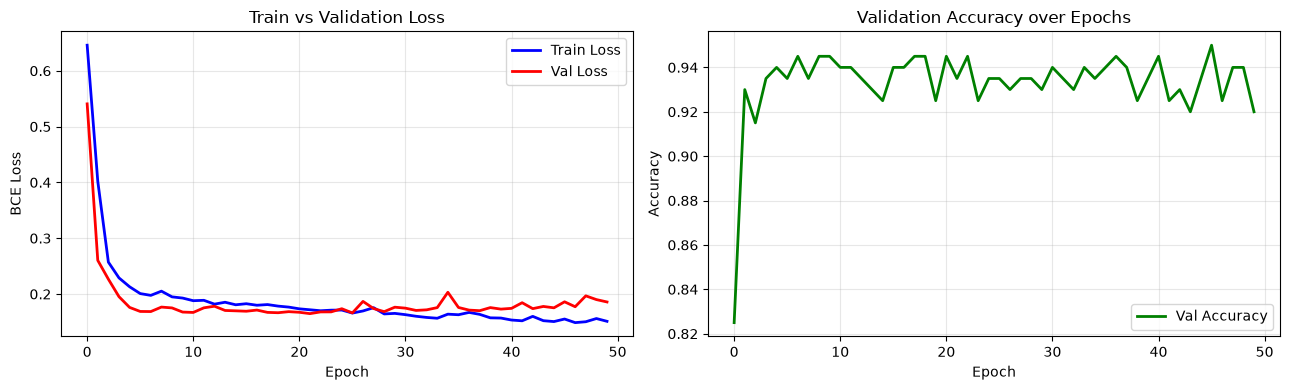

In [4]:
# Cell 4 — Version 3: plot train vs val loss + accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, 'b-', linewidth=2, label='Train Loss')
axes[0].plot(val_losses,   'r-', linewidth=2, label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(val_accs, 'g-', linewidth=2, label='Val Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Model saved to model_weights.pth ✅
Model loaded ✅
Predictions identical: True ✅


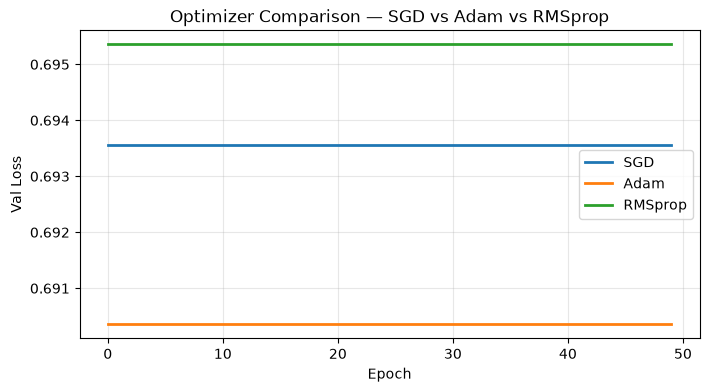

In [5]:
# Cell 5 — Version 4: save and load model
# save
torch.save(model.state_dict(), 'model_weights.pth')
print("Model saved to model_weights.pth ✅")

# load
model_loaded = Net()
model_loaded.load_state_dict(torch.load('model_weights.pth'))
model_loaded.eval()
print("Model loaded ✅")

# verify same predictions
with torch.no_grad():
    out_original = model(X_test_t)
    out_loaded   = model_loaded(X_test_t)
    same = torch.allclose(out_original, out_loaded)
    print(f"Predictions identical: {same} ✅")

# different optimizers comparison
optimizers = {
    'SGD':     optim.SGD(Net().parameters(),  lr=0.01),
    'Adam':    optim.Adam(Net().parameters(), lr=0.01),
    'RMSprop': optim.RMSprop(Net().parameters(), lr=0.01),
}

plt.figure(figsize=(8, 4))
for name, opt in optimizers.items():
    m = Net(); m.train()
    o = opt; losses_cmp = []
    for epoch in range(50):
        for X_batch, y_batch in train_loader:
            o.zero_grad()
            loss = criterion(m(X_batch), y_batch)
            loss.backward(); o.step()
        with torch.no_grad():
            losses_cmp.append(criterion(m(X_test_t), y_test_t).item())
    plt.plot(losses_cmp, linewidth=2, label=name)

plt.xlabel('Epoch'); plt.ylabel('Val Loss')
plt.title('Optimizer Comparison — SGD vs Adam vs RMSprop')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()